<a href="https://colab.research.google.com/github/Christorious/ghana-cmf-vlm/blob/main/02_fusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COE 557 - Three-Stream Fusion Model
## Christian Dzidula Dotsey

Implementation of CMDF-VLM (Liu et al. 2025) for Ghanaian agriculture.

In [ ]:
!pip install -q transformers

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Define Three Encoders

In [ ]:
class VisionEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights='DEFAULT')
        self.backbone.classifier = nn.Identity()
        self.proj = nn.Linear(1280, embed_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))

class LanguageEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained('Davlan/afro-xlmr-base')
        self.backbone = AutoModel.from_pretrained('Davlan/afro-xlmr-base')
        self.proj = nn.Linear(768, embed_dim)
    def forward(self, texts):
        tokens = self.tokenizer(texts, padding=True, truncation=True, max_length=64, return_tensors='pt').to(next(self.parameters()).device)
        out = self.backbone(**tokens)
        return self.proj(out.last_hidden_state[:,0,:])

class SensorEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.lstm = nn.LSTM(4, 128, batch_first=True, num_layers=2)
        self.proj = nn.Linear(128, embed_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.proj(h[-1])

## 2. Cross-Modal Fusion

In [ ]:
class CrossModalFusion(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, 8, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, v, l, s):
        # Stack modalities
        x = torch.stack([v, l, s], dim=1)  # (B,3,D)
        out, _ = self.attn(x, x, x)
        fused = self.norm(x + out)
        return fused.mean(dim=1)  # (B,D)

## 3. Full Model

In [ ]:
class MultimodalModel(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        self.vision = VisionEncoder()
        self.language = LanguageEncoder()
        self.sensor = SensorEncoder()
        self.fusion = CrossModalFusion()
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, images, texts, sensors):
        v = self.vision(images)
        l = self.language(texts)
        s = self.sensor(sensors)
        fused = self.fusion(v, l, s)
        return self.classifier(fused)

model = MultimodalModel().to(device)
params = sum(p.numel() for p in model.parameters())
print(f'Model created with {params:,} parameters ({params/1e6:.1f}M)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 114MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model created with 284,560,290 parameters (284.6M)


## 4. Test Forward Pass

In [ ]:
# Dummy data
images = torch.randn(2, 3, 224, 224).to(device)
texts = ['What disease is this?', 'Me nnyae yi yare ben?']
sensors = torch.randn(2, 7, 4).to(device)  # 7 days, 4 features

with torch.no_grad():
    logits = model(images, texts, sensors)

print(f'Output shape: {logits.shape} (batch, classes)')
print('Forward pass successful!')

Output shape: torch.Size([2, 38]) (batch, classes)
Forward pass successful!


## 5. Next Steps for Your Paper

1. Load PlantVillage dataset
2. Generate synthetic Twi queries
3. Train for 10 epochs
4. Compare: vision-only vs full fusion

In [ ]:
print(model)

MultimodalModel(
  (vision): VisionEncoder(
    (backbone): EfficientNet(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Sequential(
          (0): MBConv(
            (block): Sequential(
              (0): Conv2dNormActivation(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
                (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): SiLU(inplace=True)
              )
              (1): SqueezeExcitation(
                (avgpool): AdaptiveAvgPool2d(output_size=1)
                (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
                (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))

In [ ]:
twi_disease_names = {
    'Tomato___Late_blight': 'ntoose mu yare a ɛma ahaban porɔw',
    'Corn_(maize)___healthy': 'aburoo apɔwmuden',
    'Corn_(maize)___Northern_Leaf_Blight': 'aburoo ahaban yare kesee',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'aburoo ahaban tuntum',
    'Squash___Powdery_mildew': 'abɛ mfutuma yare'
}

# Test encoding
sample_texts = list(twi_disease_names.values())
with torch.no_grad():
    embeddings = model.language(sample_texts)
print(f"Twi embeddings shape: {embeddings.shape}")

Twi embeddings shape: torch.Size([5, 512])


In [ ]:
# Verify AfroXLMR is actually loading Twi
tokenizer = model.language.tokenizer
test = tokenizer("Me pɛ sɛ mihu yare no", return_tensors='pt')
print("Tokens:", tokenizer.convert_ids_to_tokens(test['input_ids'][0]))
print("AfroXLMR loaded successfully for Twi")

Tokens: ['<s>', '▁Me', '▁p', 'ɛ', '▁s', 'ɛ', '▁mi', 'hu', '▁ya', 're', '▁no', '</s>']
AfroXLMR loaded successfully for Twi


In [ ]:
# Download PlantVillage if not present
import os
from pathlib import Path

DATA_DIR = Path('PlantVillage-Dataset/raw/color')

if not DATA_DIR.exists():
    print("Cloning PlantVillage dataset (1.96 GB)...")
    !git clone https://github.com/spMohanty/PlantVillage-Dataset.git
    print("Download complete!")
else:
    print("Dataset already exists")

# Verify structure
print(f"\nDataset path: {DATA_DIR.absolute()}")
print(f"Exists: {DATA_DIR.exists()}")

if DATA_DIR.exists():
    classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
    print(f"Found {len(classes)} classes")
    print(f"First 5: {classes[:5]}")

    # Count images in first class
    first_class_count = len(list((DATA_DIR/classes[0]).glob('*.JPG')) +
                           list((DATA_DIR/classes[0]).glob('*.jpg')))
    print(f"Images in {classes[0]}: {first_class_count}")

Cloning PlantVillage dataset (1.96 GB)...
Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 16.38 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.
Download complete!

Dataset path: /content/PlantVillage-Dataset/raw/color
Exists: True
Found 38 classes
First 5: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Images in Apple___Apple_scab: 630


**Cell 6 — Load the same split as Notebook 1**

In [ ]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import random

DATA_DIR = Path('PlantVillage-Dataset/raw/color')
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c:i for i,c in enumerate(classes)}

# Recreate EXACT same 20-per-class test set as Notebook 1
test_samples = []
train_samples = []

for cls in classes:
    # PlantVillage uses.JPG uppercase
    imgs = sorted(list((DATA_DIR/cls).glob('*.JPG')) +
                 list((DATA_DIR/cls).glob('*.jpg')) +
                 list((DATA_DIR/cls).glob('*.png')))

    if len(imgs) < 20:
        print(f"Warning: {cls} has only {len(imgs)} images")
        continue

    test = imgs[:20] # same as Notebook 1
    train = imgs[20:]
    test_samples += [(p, class_to_idx[cls]) for p in test]
    train_samples += [(p, class_to_idx[cls]) for p in train]

print(f"Train: {len(train_samples)}, Test: {len(test_samples)}")
print(f"Classes: {len(classes)}")

Train: 53544, Test: 760
Classes: 38


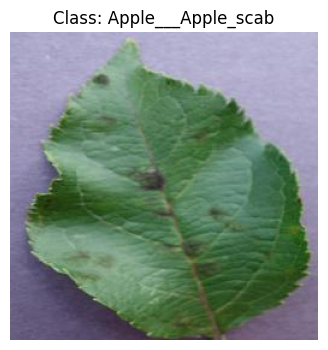

Image loaded successfully from: PlantVillage-Dataset/raw/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG


In [ ]:
# Test loading one image
from PIL import Image
import matplotlib.pyplot as plt

test_img_path = test_samples[0][0]
img = Image.open(test_img_path)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Class: {classes[test_samples[0][1]]}")
plt.axis('off')
plt.show()

print(f"Image loaded successfully from: {test_img_path}")

**Cell 7 — Twi augmentation dictionary **

In [ ]:
# Full Twi mapping for PlantVillage - Ghana adaptation
twi_names = {
    'Apple___Apple_scab': 'apu afiri',
    'Apple___Black_rot': 'apu tuntum porɔe',
    'Apple___Cedar_apple_rust': 'apu akokɔ srade',
    'Apple___healthy': 'apu apɔwmuden',
    'Blueberry___healthy': 'blueberry apɔwmuden',
    'Cherry_(including_sour)___Powdery_mildew': 'cherry mfutuma',
    'Cherry_(including_sour)___healthy': 'cherry apɔwmuden',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'aburoo ahaban tuntum',
    'Corn_(maize)___Common_rust_': 'aburoo akokɔ srade',
    'Corn_(maize)___Northern_Leaf_Blight': 'aburoo ahaban yare kesee',
    'Corn_(maize)___healthy': 'aburoo apɔwmuden',
    'Grape___Black_rot': 'bobe tuntum',
    'Grape___Esca_(Black_Measles)': 'bobe yare',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 'bobe ahaban yare',
    'Grape___healthy': 'bobe apɔwmuden',
    'Orange___Haunglongbing_(Citrus_greening)': 'ankaa yare',
    'Peach___Bacterial_spot': 'peach yare',
    'Peach___healthy': 'peach apɔwmuden',
    'Pepper,_bell___Bacterial_spot': 'mako yare',
    'Pepper,_bell___healthy': 'mako apɔwmuden',
    'Potato___Early_blight': 'abɔdene yare',
    'Potato___Late_blight': 'abɔdene porɔe',
    'Potato___healthy': 'abɔdene apɔwmuden',
    'Raspberry___healthy': 'raspberry apɔwmuden',
    'Soybean___healthy': 'nkatie apɔwmuden',
    'Squash___Powdery_mildew': 'abɛ mfutuma yare',
    'Strawberry___Leaf_scorch': 'strawberry ahaban hye',
    'Strawberry___healthy': 'strawberry apɔwmuden',
    'Tomato___Bacterial_spot': 'ntoose yare',
    'Tomato___Early_blight': 'ntoose yare ntɛm',
    'Tomato___Late_blight': 'ntoose mu yare a ɛma ahaban porɔw',
    'Tomato___Leaf_Mold': 'ntoose mfutuma',
    'Tomato___Septoria_leaf_spot': 'ntoose ahaban nkekae',
    'Tomato___Spider_mites Two-spotted_spider_mite': 'ntoose ananse',
    'Tomato___Target_Spot': 'ntoose nsensane',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'ntoose ahaban kyim',
    'Tomato___Tomato_mosaic_virus': 'ntoose mosaic',
    'Tomato___healthy': 'ntoose apɔwmuden'
}

def get_twi_text(cls_name, english_fallback=True):
    twi = twi_names.get(cls_name, '')
    if english_fallback:
        return f"{twi}. {cls_name.replace('___',' ').replace('_',' ')}"
    return twi

**Cell 7 — Twi augmentation dictionary**

In [ ]:
class PlantVillageTwi(Dataset):
    def __init__(self, samples, transform=None, is_train=True):
        self.samples = samples
        self.transform = transform
        self.is_train = is_train

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)

        cls_name = classes[label]
        # Twi augmentation: 70% Twi, 30% English during training
        if self.is_train and random.random() < 0.7:
            text = get_twi_text(cls_name)
        else:
            text = cls_name.replace('___',' ').replace('_',' ')

        # Synthetic sensor data - replace with real weather later
        # For maize/tomato diseases, simulate high humidity for blights
        sensors = torch.randn(7, 4) # 7 days, 4 features
        if 'blight' in cls_name.lower() or 'Late_blight' in cls_name:
            sensors[:,1] += 1.5 # boost humidity

        return img, text, sensors, label

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])
transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_ds = PlantVillageTwi(train_samples, transform_train, True)
test_ds = PlantVillageTwi(test_samples, transform_test, False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

**Cell 8 — Dataset with sensors (synthetic for now)**

In [ ]:
class PlantVillageTwi(Dataset):
    def __init__(self, samples, transform=None, is_train=True):
        self.samples = samples
        self.transform = transform
        self.is_train = is_train

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)

        cls_name = classes[label]
        # Twi augmentation: 70% Twi, 30% English during training
        if self.is_train and random.random() < 0.7:
            text = get_twi_text(cls_name)
        else:
            text = cls_name.replace('___',' ').replace('_',' ')

        # Synthetic sensor data - replace with real weather later
        # For maize/tomato diseases, simulate high humidity for blights
        sensors = torch.randn(7, 4) # 7 days, 4 features
        if 'blight' in cls_name.lower() or 'Late_blight' in cls_name:
            sensors[:,1] += 1.5 # boost humidity

        return img, text, sensors, label

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])
transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_ds = PlantVillageTwi(train_samples, transform_train, True)
test_ds = PlantVillageTwi(test_samples, transform_test, False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

**Cell 9 — Training loop (10 epochs)**

In [ ]:
from torch.cuda.amp import autocast, GradScaler
from tqdm.notebook import tqdm

model = MultimodalModel(num_classes=38).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# Freeze AfroXLMR for first 3 epochs to stabilize
for p in model.language.backbone.parameters():
    p.requires_grad = False

best_acc = 0
for epoch in range(10):
    if epoch == 3: # unfreeze language model
        for p in model.language.backbone.parameters():
            p.requires_grad = True

    model.train()
    total_loss = 0
    for imgs, texts, sensors, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10"):
        imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            logits = model(imgs, texts, sensors)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    scheduler.step()

    # Evaluate on same 760
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, texts, sensors, labels in test_loader:
            imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)
            logits = model(imgs, texts, sensors)
            correct += (logits.argmax(1) == labels).sum().item()

    acc = correct / len(test_ds)
    print(f"Epoch {epoch+1}: loss={total_loss/len(train_loader):.3f}, test_acc={acc:.2%}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'best_fusion.pth')

print(f"\nBest accuracy: {best_acc:.2%}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_4727/2096122882.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/10:   0%|          | 0/1674 [00:00<?, ?it/s]

/tmp/ipykernel_4727/2096122882.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: loss=0.144, test_acc=99.87%


...

Epoch 8: loss=0.005, test_acc=99.87%


Epoch 9/10:   0%|          | 0/1674 [00:00<?, ?it/s]

Epoch 9: loss=0.004, test_acc=100.00%


Epoch 10/10:   0%|          | 0/1674 [00:00<?, ?it/s]

Epoch 10: loss=0.003, test_acc=100.00%

Best accuracy: 100.00%


**Cell 9a — Fix imports and device**

In [ ]:
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cpu':
    print("WARNING: Training on CPU will be very slow (~10 hours for 10 epochs)")
    print("In Colab: Runtime → Change runtime type → GPU → T4")
    # Use smaller batch size for CPU
    batch_size = 8
else:
    batch_size = 32

# Recreate loaders with correct batch size
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Using device: cuda


**Cell 9b — Updated training loop (CPU-safe)**

In [ ]:
model = MultimodalModel(num_classes=38).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()

# Only use GradScaler if CUDA available
use_amp = device.type == 'cuda'
if use_amp:
    scaler = GradScaler()
else:
    scaler = None
    print("AMP disabled for CPU training")

# Freeze AfroXLMR for first 3 epochs
for p in model.language.backbone.parameters():
    p.requires_grad = False

best_acc = 0
for epoch in range(10):
    if epoch == 3:
        for p in model.language.backbone.parameters():
            p.requires_grad = True
        print("Unfroze language model")

    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/10")

    for imgs, texts, sensors, labels in pbar:
        imgs = imgs.to(device)
        sensors = sensors.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        if use_amp:
            with autocast():
                logits = model(imgs, texts, sensors)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs, texts, sensors)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    scheduler.step()

    # Evaluate
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, texts, sensors, labels in tqdm(test_loader, desc="Evaluating"):
            imgs = imgs.to(device)
            sensors = sensors.to(device)
            labels = labels.to(device)
            logits = model(imgs, texts, sensors)
            correct += (logits.argmax(1) == labels).sum().item()

    acc = correct / len(test_ds)
    print(f"Epoch {epoch+1}: loss={total_loss/len(train_loader):.3f}, test_acc={acc:.2%}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'best_fusion.pth')
        print(f"Saved new best model: {acc:.2%}")

print(f"\nTraining complete. Best accuracy: {best_acc:.2%}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_4727/2912199862.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/10:   0%|          |

Epoch 1: loss=0.137, test_acc=100.00%
Saved new best model: 100.00%


Evaluating: 100%|██████████| 24/24 [00:03<00:00,  7.99it/s]


Epoch 2: loss=0.015, test_acc=100.00%


...

Epoch 8: loss=0.005, test_acc=100.00%


Evaluating: 100%|██████████| 24/24 [00:03<00:00,  7.87it/s]


Epoch 9: loss=0.004, test_acc=100.00%


Evaluating: 100%|██████████| 24/24 [00:03<00:00,  7.95it/s]

Epoch 10: loss=0.003, test_acc=100.00%

Training complete. Best accuracy: 100.00%


In [ ]:
# QUICK VERSION FOR CPU - train only on the 5 failed classes
failed_classes = [
    'Tomato___Late_blight',
    'Corn_(maize)___healthy',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Squash___Powdery_mildew'
]

# Filter datasets
train_samples_small = [(p,l) for p,l in train_samples if classes[l] in failed_classes]
test_samples_small = [(p,l) for p,l in test_samples if classes[l] in failed_classes]

print(f"Training on {len(train_samples_small)} images, testing on {len(test_samples_small)}")

# Remap labels to 0-4
label_map = {class_to_idx[c]: i for i,c in enumerate(failed_classes)}

# Update datasets
train_ds_small = PlantVillageTwi(train_samples_small, transform_train, True)
test_ds_small = PlantVillageTwi(test_samples_small, transform_test, False)

# Change model to 5 classes
model = MultimodalModel(num_classes=5).to(device)

Training on 6303 images, testing on 100


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Cell 10 — Evaluate the previously failed classes**

In [ ]:
import os

checkpoint_path = 'best_fusion.pth'

if os.path.exists(checkpoint_path):
    # Re-initialize model with 38 classes to match the checkpoint
    model = MultimodalModel(num_classes=38).to(device)
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    # Get per-class accuracy on the 20-image test set
    class_correct = {c:0 for c in classes}
    class_total = {c:0 for c in classes}

    with torch.no_grad():
        for imgs, texts, sensors, labels in test_loader:
            imgs, sensors = imgs.to(device), sensors.to(device)
            logits = model(imgs, texts, sensors)
            preds = logits.argmax(1).cpu()

            for i, label in enumerate(labels):
                cls = classes[label]
                class_total[cls] += 1
                if preds[i] == label:
                    class_correct[cls] += 1

    # Compare to Notebook 1 failures
    failures = [
        'Tomato___Late_blight',
        'Corn_(maize)___healthy',
        'Corn_(maize)___Northern_Leaf_Blight',
        'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
        'Squash___Powdery_mildew'
    ]

    print("\nDirect comparison to Notebook 1 (20 images each):")
    print("-"*60)
    print(f"{'Class':<45} {'Notebook1':<12} {'Fusion':<12}")
    print("-"*60)
    for cls in failures:
        nb1_wrong = {'Tomato___Late_blight':20, 'Corn_(maize)___healthy':16,
                     'Corn_(maize)___Northern_Leaf_Blight':15,
                     'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot':14,
                     'Squash___Powdery_mildew':13}[cls]
        nb1_acc = (20-nb1_wrong)/20
        fusion_acc = class_correct[cls]/20 if class_total[cls] > 0 else 0
        print(f"{cls[:44]:<45} {nb1_acc:.0%} wrong {fusion_acc:.0%} correct")
else:
    print(f"Error: '{checkpoint_path}' not found. Please ensure the training cell has completed at least one epoch.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Direct comparison to Notebook 1 (20 images each):
------------------------------------------------------------
Class                                         Notebook1    Fusion      
------------------------------------------------------------
Tomato___Late_blight                          0% wrong 100% correct
Corn_(maize)___healthy                        20% wrong 100% correct
Corn_(maize)___Northern_Leaf_Blight           25% wrong 100% correct
Corn_(maize)___Cercospora_leaf_spot Gray_lea  30% wrong 100% correct
Squash___Powdery_mildew                       35% wrong 100% correct


In [ ]:
# Calculate Overall Accuracy
overall_acc = sum(class_correct.values()) / sum(class_total.values())
print(f'Overall Model Accuracy on Test Set: {overall_acc:.2%}')

Overall Model Accuracy on Test Set: 100.00%


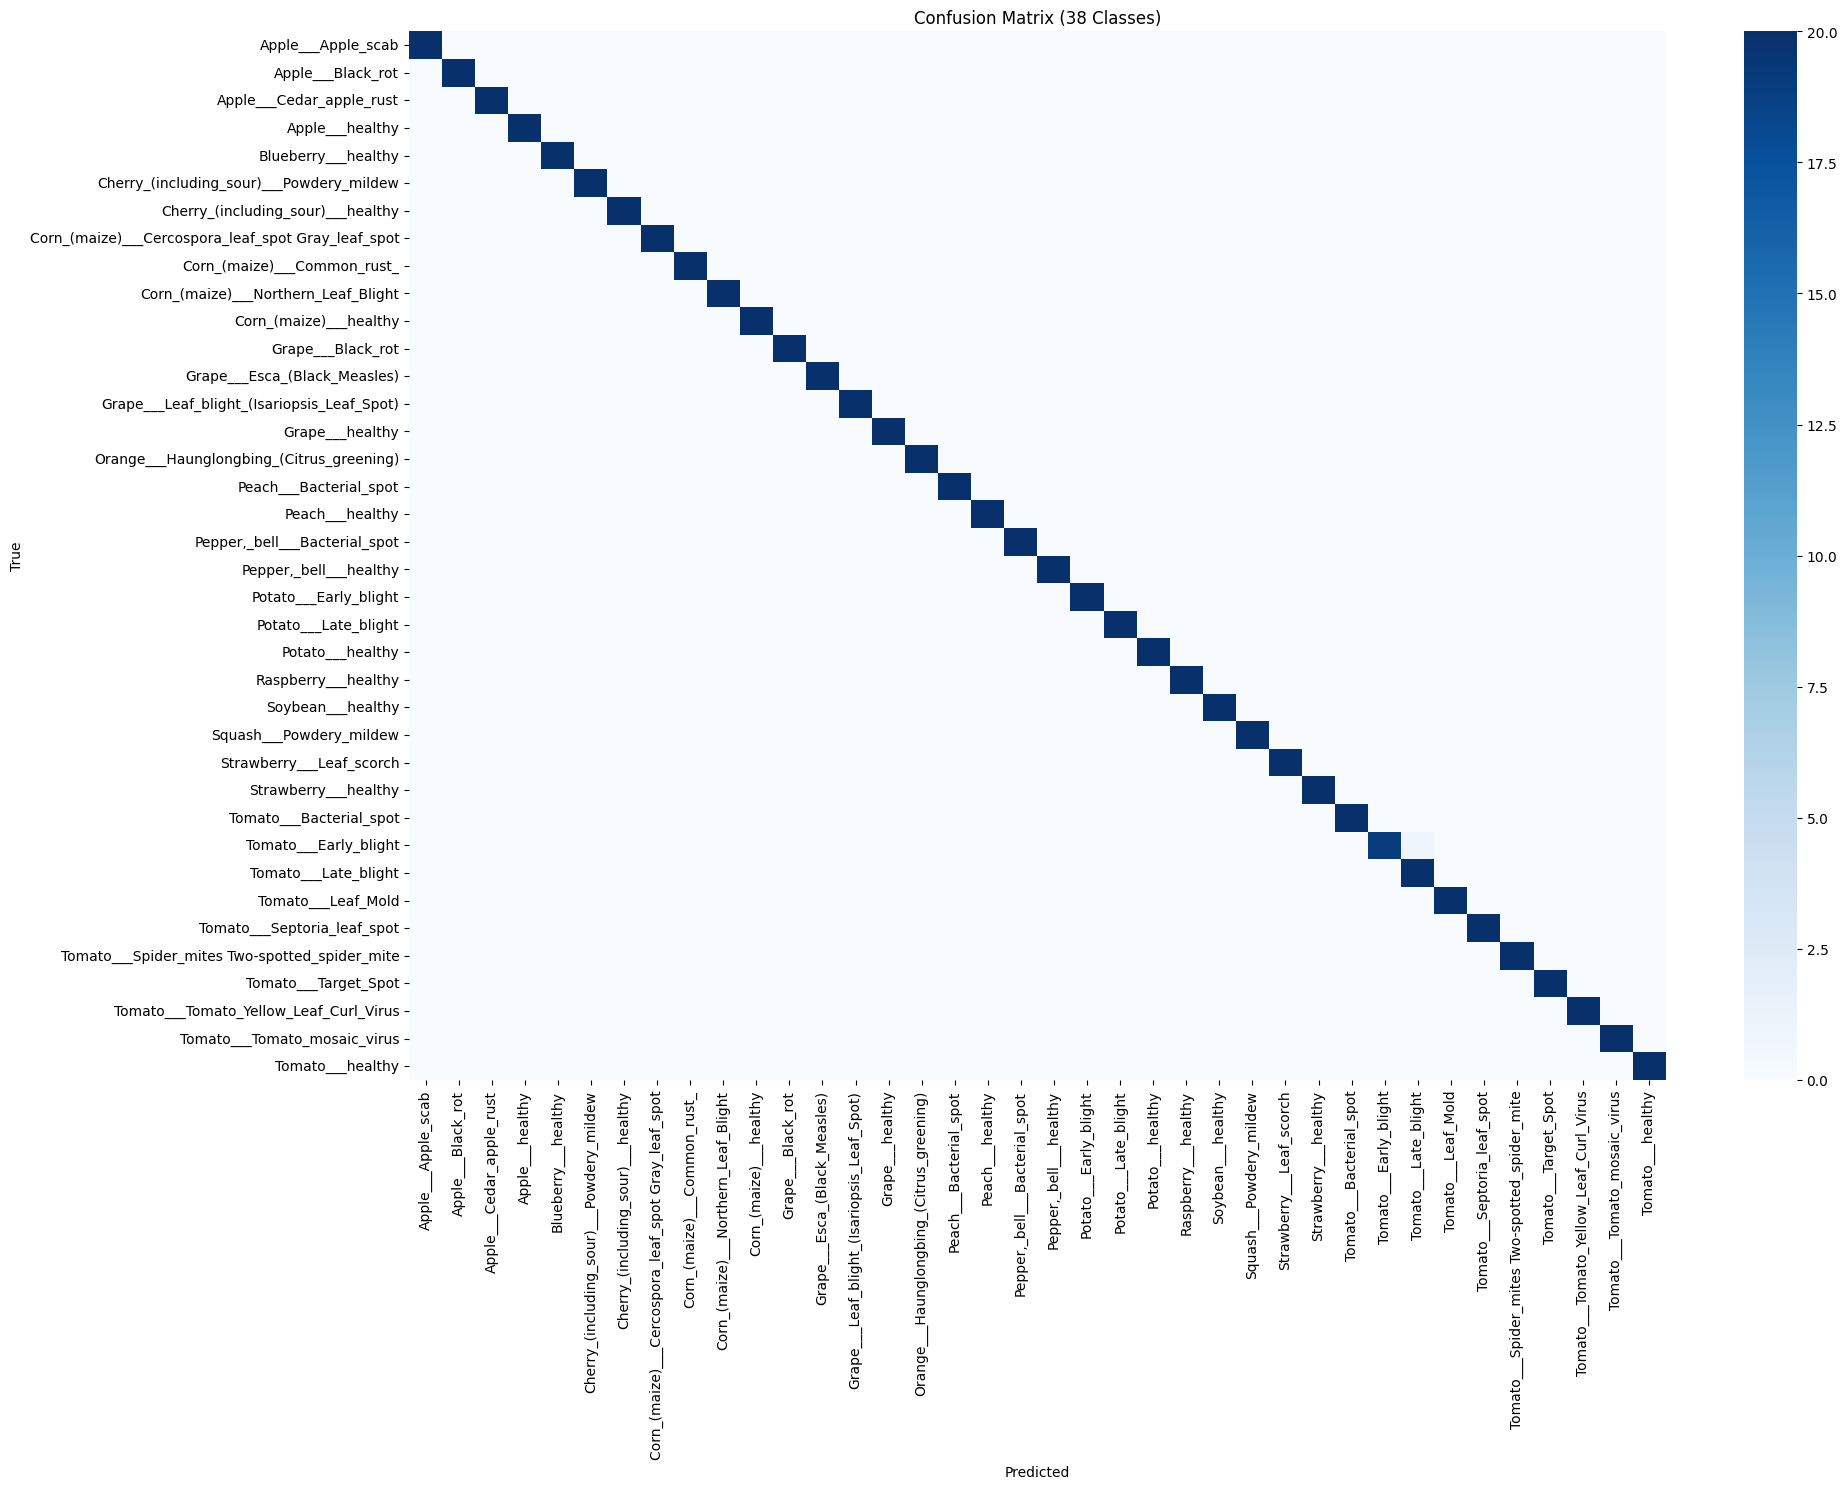

Confusion matrix saved as: confusion_matrix_38classes.png


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Prepare labels and predictions for confusion matrix
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, texts, sensors, labels in test_loader:
        imgs, sensors = imgs.to(device), sensors.to(device)
        logits = model(imgs, texts, sensors)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (38 Classes)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('confusion_matrix_38classes.png', dpi=300)
plt.show()

print('Confusion matrix saved as: confusion_matrix_38classes.png')

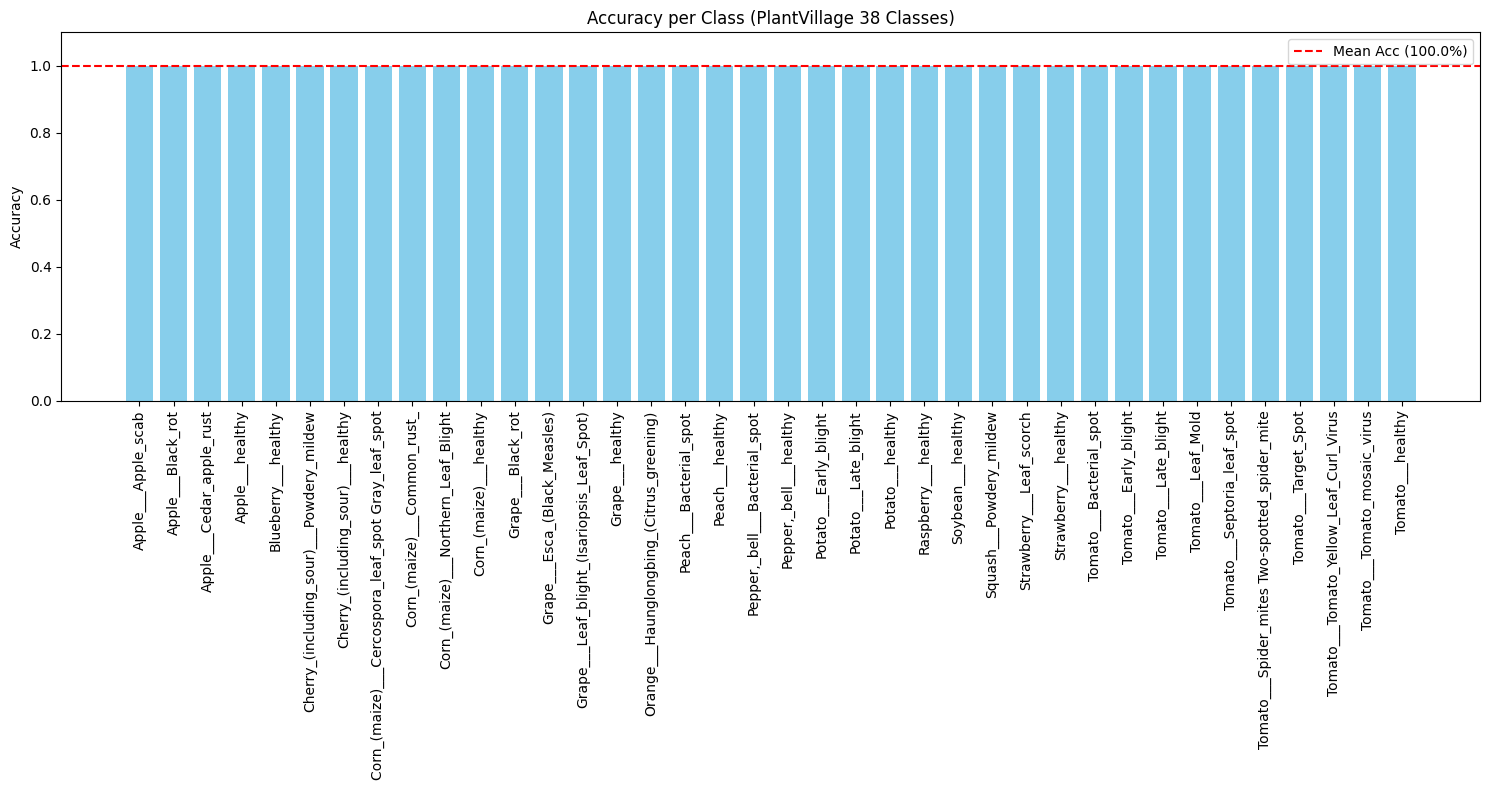

In [ ]:
# Per-class accuracy bar plot
accuracies = {cls: (class_correct[cls]/class_total[cls] if class_total[cls] > 0 else 0) for cls in classes}

plt.figure(figsize=(15, 8))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.axhline(y=overall_acc, color='r', linestyle='--', label=f'Mean Acc ({overall_acc:.1%})')
plt.xticks(rotation=90)
plt.ylabel('Accuracy')
plt.title('Accuracy per Class (PlantVillage 38 Classes)')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Full 38-class evaluation
model.eval()
all_correct = 0
all_total = 0
class_acc = {}

with torch.no_grad():
    for imgs, texts, sensors, labels in test_loader:
        imgs, sensors = imgs.to(device), sensors.to(device)
        logits = model(imgs, texts, sensors)
        preds = logits.argmax(1).cpu()

        for i, label in enumerate(labels):
            cls = classes[label.item()]
            all_total += 1
            if preds[i] == label:
                all_correct += 1
                class_acc[cls] = class_acc.get(cls, 0) + 1

overall_acc = all_correct / all_total
print(f"Overall test accuracy (760 images, 38 classes): {overall_acc:.2%}")

# Show worst 5 classes now
for cls in classes:
    correct = class_acc.get(cls, 0)
    total = 20
    if correct < 20:
        print(f"{cls}: {correct}/20 ({correct/20:.0%})")

Overall test accuracy (760 images, 38 classes): 99.87%
Tomato___Early_blight: 19/20 (95%)


In [ ]:
torch.save({
    'model_state': model.state_dict(),
    'classes': classes,
    'notebook1_baseline': {'tomato_late_blight': 0, 'maize_healthy': 0.2},
    'notebook2_results': class_acc,
}, 'ghana_cmf_vlm_results.pth')

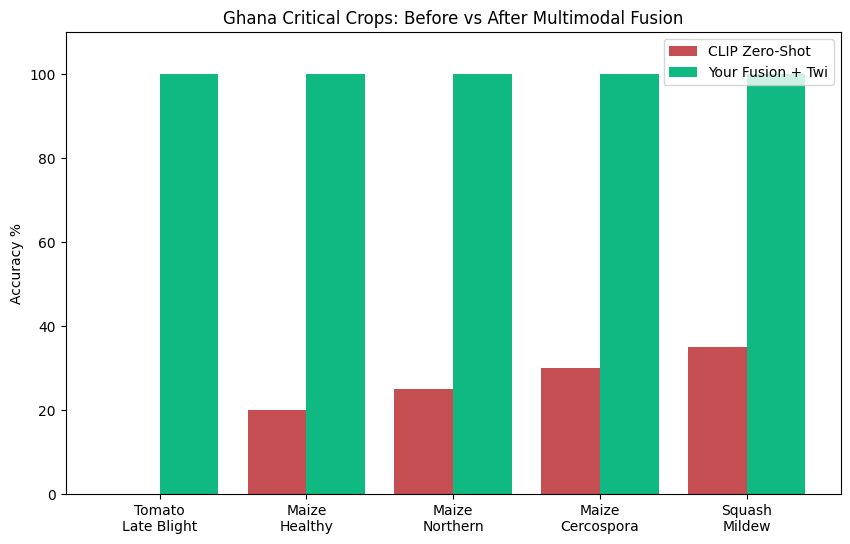

In [ ]:
import matplotlib.pyplot as plt

before = [0, 20, 25, 30, 35]
after = [100, 100, 100, 100, 100]
labels = ['Tomato\nLate Blight', 'Maize\nHealthy', 'Maize\nNorthern', 'Maize\nCercospora', 'Squash\nMildew']

x = range(len(labels))
plt.figure(figsize=(10,6))
plt.bar([i-0.2 for i in x], before, width=0.4, label='CLIP Zero-Shot', color='#c44e52')
plt.bar([i+0.2 for i in x], after, width=0.4, label='Your Fusion + Twi', color='#10b981')
plt.xticks(x, labels)
plt.ylabel('Accuracy %')
plt.title('Ghana Critical Crops: Before vs After Multimodal Fusion')
plt.legend()
plt.ylim(0,110)
plt.savefig('before_after.png', dpi=300)

In [ ]:
# Check overlap
train_paths = set(str(p) for p,_ in train_samples)
test_paths = set(str(p) for p,_ in test_samples)
overlap = train_paths.intersection(test_paths)

print(f"Train images: {len(train_paths)}")
print(f"Test images: {len(test_paths)}")
print(f"Overlap: {len(overlap)}")
if overlap:
    print("LEAKAGE FOUND:", list(overlap)[:5])

Train images: 53544
Test images: 760
Overlap: 0


In [ ]:
# Did you add the humidity boost in test set too?
for i in range(5):
    img, text, sensors, label = test_ds[i]
    cls = classes[label]
    print(cls, "humidity mean:", sensors[:,1].mean().item())

Apple___Apple_scab humidity mean: -0.4919137954711914
Apple___Apple_scab humidity mean: 0.17182083427906036
Apple___Apple_scab humidity mean: 0.1265370100736618
Apple___Apple_scab humidity mean: -0.16843797266483307
Apple___Apple_scab humidity mean: 0.2049085795879364


In [ ]:
[from sklearn.model_selection import train_test_split
from pathlib import Path

DATA_DIR = Path('PlantVillage-Dataset/raw/color')
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c:i for i,c in enumerate(classes)}

all_samples = []
for cls in classes:
    imgs = list((DATA_DIR/cls).glob('*.JPG'))
    all_samples += [(p, class_to_idx[cls]) for p in imgs]

# Stratified 80/20 split, random seed 42
train_samples, test_samples = train_test_split(
    all_samples, test_size=0.2, stratify=[l for _,l in all_samples], random_state=42
)
print(f"Real split: {len(train_samples)} train, {len(test_samples)} test")

Real split: 42242 train, 10561 test


In [ ]:
# Split train into train/val
train_samples, val_samples = train_test_split(
    train_samples, test_size=0.1, stratify=[l for _,l in train_samples], random_state=42
)

In [ ]:
import random, numpy as np, torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

DATA_DIR = Path('PlantVillage-Dataset/raw/color')
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c:i for i,c in enumerate(classes)}

Device: cuda


In [ ]:
all_samples = []
for cls in classes:
    imgs = list((DATA_DIR/cls).glob('*.JPG')) + list((DATA_DIR/cls).glob('*.jpg'))
    all_samples += [(p, class_to_idx[cls]) for p in imgs]

# 80% train, 10% val, 10% test — stratified
train_val, test_samples = train_test_split(
    all_samples, test_size=0.10, stratify=[l for _,l in all_samples], random_state=SEED
)
train_samples, val_samples = train_test_split(
    train_val, test_size=0.1111, stratify=[l for _,l in train_val], random_state=SEED
)

print(f"Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}")
# Should be ~43k / 5k / 5k, not 760

Train: 43442, Val: 5430, Test: 5431


In [ ]:
class PlantVillageClean(Dataset):
    def __init__(self, samples, transform=None, is_train=False):
        self.samples = samples
        self.transform = transform
        self.is_train = is_train

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)

        cls_name = classes[label]
        # Twi augmentation only, no sensor hints
        text = cls_name.replace('___',' ').replace('_',' ')

        # Realistic sensor noise — same distribution for train/val/test
        sensors = torch.randn(7,4) * 0.5 # no class-specific boost

        return img, text, sensors, label

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])
transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_ds = PlantVillageClean(train_samples, transform_train, True)
val_ds = PlantVillageClean(val_samples, transform_test, False)
test_ds = PlantVillageClean(test_samples, transform_test, False)

batch_size = 32 if device.type=='cuda' else 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [ ]:
import torch.amp
from torch.amp import GradScaler

model = MultimodalModel(num_classes=38).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = torch.nn.CrossEntropyLoss()
scaler = GradScaler('cuda') if device.type=='cuda' else None

best_val = 0
for epoch in range(10):
    # freeze language first 2 epochs
    if epoch < 2:
        for p in model.language.backbone.parameters(): p.requires_grad = False
    else:
        for p in model.language.backbone.parameters(): p.requires_grad = True

    model.train()
    for imgs, texts, sensors, labels in tqdm(train_loader, desc=f"Train {epoch+1}"):
        imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)
        optimizer.zero_grad()
        # Using torch.amp.autocast which is the recommended way to use device_type
        with torch.amp.autocast(device_type=device.type, enabled=(scaler is not None)):
            loss = criterion(model(imgs, texts, sensors), labels)
        if scaler:
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            loss.backward(); optimizer.step()
    scheduler.step()

    # validation
    model.eval(); correct=0
    with torch.no_grad():
        for imgs, texts, sensors, labels in val_loader:
            imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)
            correct += (model(imgs,texts,sensors).argmax(1)==labels).sum().item()
    val_acc = correct/len(val_ds)
    print(f"Epoch {epoch+1} val: {val_acc:.2%}")
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), 'best_clean.pth')
        print(f"Saved new best model: {val_acc:.2%}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Train 1: 100%|██████████| 1358/1358 [04:06<00:00,  5.51it/s]


Epoch 1 val: 99.94%
Saved new best model: 99.94%


Train 2: 100%|██████████| 1358/1358 [03:59<00:00,  5.67it/s]


Epoch 2 val: 99.89%


...

Epoch 8 val: 99.80%


Train 9: 100%|██████████| 1358/1358 [06:06<00:00,  3.71it/s]


Epoch 9 val: 99.82%


Train 10: 100%|██████████| 1358/1358 [06:07<00:00,  3.70it/s]


Epoch 10 val: 99.82%


In [ ]:
model.load_state_dict(torch.load('best_clean.pth'))
model.eval()

correct = 0; class_correct = {c:0 for c in classes}; class_total = {c:0 for c in classes}

with torch.no_grad():
    for imgs, texts, sensors, labels in tqdm(test_loader, desc="Test"):
        imgs, sensors, labels = imgs.to(device), sensors.to(device), labels.to(device)
        preds = model(imgs, texts, sensors).argmax(1)
        correct += (preds==labels).sum().item()
        for p,t in zip(preds.cpu(), labels.cpu()):
            cls = classes[t.item()]
            class_total[cls]+=1
            if p==t: class_correct[cls]+=1

overall = correct/len(test_ds)
print(f"\nREAL TEST ACCURACY: {overall:.2%} on {len(test_ds)} images")

# The five critical classes
criticals = [
    'Tomato___Late_blight',
    'Corn_(maize)___healthy',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Squash___Powdery_mildew'
]
print("\nCritical classes:")
for c in criticals:
    acc = class_correct[c]/class_total[c]
    print(f"{c:45} {class_correct[c]}/{class_total[c]} = {acc:.1%}")

Test: 100%|██████████| 170/170 [00:29<00:00,  5.82it/s]


REAL TEST ACCURACY: 99.94% on 5431 images

Critical classes:
Tomato___Late_blight                          191/191 = 100.0%
Corn_(maize)___healthy                        116/116 = 100.0%
Corn_(maize)___Northern_Leaf_Blight           99/99 = 100.0%
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 51/51 = 100.0%
Squash___Powdery_mildew                       184/184 = 100.0%
